# Notebook 9 – Categorical Data Analysis

# 1. Creating a Sample Dataset

We will create a small dataset containing categorical and numerical features.

The dataset contains information about customers, their city, gender, membership type, and whether they purchased a product.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Customer": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"],
    "City": [
        "Chennai", "Chennai", "Delhi", "Delhi", "Mumbai",
        "Mumbai", "Chennai", "Kolkata", "Kolkata", "Pune"
    ],
    "Gender": [
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Male"
    ],
    "Membership": [
        "Gold", "Silver", "Gold", "Bronze", "Silver",
        "Gold", "Gold", "Silver", "Bronze", "Gold"
    ],
    "Purchased": [
        "Yes", "No", "Yes", "No", "Yes",
        "Yes", "No", "No", "Yes", "Yes"
    ]
})

df

,Customer,City,Gender,Membership,Purchased
0,A,Chennai,Male,Gold,Yes
1,B,Chennai,Female,Silver,No
2,C,Delhi,Male,Gold,Yes
3,D,Delhi,Female,Bronze,No
4,E,Mumbai,Male,Silver,Yes
5,F,Mumbai,Female,Gold,Yes
6,G,Chennai,Male,Gold,No
7,H,Kolkata,Female,Silver,No
8,I,Kolkata,Male,Bronze,Yes
9,J,Pune,Male,Gold,Yes


# 2. Unique Categories

## Concept

Unique categories are the different values present inside a categorical column.

For example, the Gender column may contain two categories:

- Male
- Female

Finding unique categories helps us understand what types of values exist in a categorical feature.

## Business Example

A company can check all the different cities from which its customers come.

## AI/ML Example

Before encoding categorical features, we need to know what categories are present.

In [2]:
df["City"].unique()

array(['Chennai', 'Delhi', 'Mumbai', 'Kolkata', 'Pune'], dtype=object)

## Explanation

`unique()` returns all different values present in the selected column.

This helps us identify the categories available in the dataset.

In [3]:
df["City"].nunique()

5

`nunique()` returns the number of unique categories.

For example, if the City column contains Chennai, Delhi, Mumbai, Kolkata and Pune, there are 5 unique categories.

# 3. Category Frequencies

## Concept

Category frequency tells us how many times each category occurs in a column.

For example, we can count how many customers belong to each city.

## Business Example

A company can count how many customers come from each region.

## AI/ML Example

Frequency analysis helps us understand whether some categories occur very often while others occur rarely.

In [4]:
df["City"].value_counts()

,count
City,
Chennai,3
Delhi,2
Mumbai,2
Kolkata,2
Pune,1


## Explanation

`value_counts()` counts the number of occurrences of each category.

The category with the highest count appears first by default.

This helps us quickly understand the frequency of categorical values.

# 4. Category Distribution

## Concept

Category distribution shows how the observations are divided among different categories.

Frequency tells us the count, while distribution helps us understand how those counts are spread across categories.

We can also calculate percentages to make comparison easier.

In [5]:
city_distribution = df["City"].value_counts(normalize=True) * 100

city_distribution

,proportion
City,
Chennai,30.0
Delhi,20.0
Mumbai,20.0
Kolkata,20.0
Pune,10.0


## Explanation

`normalize=True` converts the frequency into proportions.

Multiplying by 100 converts the proportions into percentages.

For example, if a city represents 30% of the dataset, then 30% of the observations belong to that city.

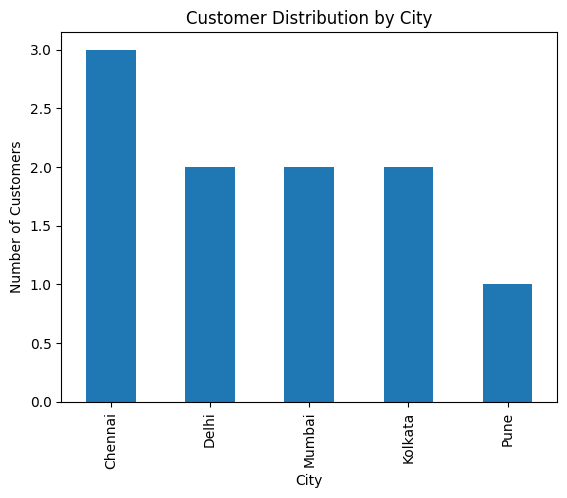

In [6]:
df["City"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.show()

## Interpretation

The bar chart shows how many customers belong to each city.

Taller bars represent categories with more observations.

# 5. Rare Categories

## Concept

A rare category is a category that occurs very few times in a dataset.

For example, if most cities have many customers but one city has only one customer, that city can be considered a rare category.

There is no single universal percentage that defines a rare category. The threshold depends on the dataset and the problem.

## Business Example

A company may have customers from many cities, but some cities may have only a few customers.

## AI/ML Example

Rare categories can sometimes create problems during encoding and model training. They may be grouped into an "Other" category depending on the problem.

In [7]:
city_counts = df["City"].value_counts()

rare_categories = city_counts[city_counts <= 1]

rare_categories

,count
City,
Pune,1


## Explanation

Here we consider categories with one or fewer observations as rare.

The condition:

`city_counts <= 1`

selects categories that occur only once.

The threshold can be changed depending on the dataset.

# 6. High Cardinality

## Concept

Cardinality means the number of unique values in a categorical feature.

High cardinality means a categorical column contains a large number of unique categories compared with the number of observations.

For example, a Customer_ID column may have almost one unique value for every customer.

## Business Example

A customer ID column can have thousands or millions of unique values.

## AI/ML Example

High-cardinality features can create a very large number of encoded features when techniques such as one-hot encoding are used.

Therefore, high-cardinality columns need to be handled carefully.

In [8]:
df["Customer"].nunique()

10

## Explanation

The Customer column has many unique values relative to the dataset size.

We can compare the number of unique values with the total number of rows.

A feature with a very large number of unique categories may be considered high cardinality.

In [9]:
for column in df.select_dtypes(include="object"):
    print(column, ":", df[column].nunique())

Customer : 10
City : 5
Gender : 2
Membership : 3
Purchased : 2


# 7. Low Cardinality

## Concept

Low cardinality means a categorical feature contains only a small number of unique categories.

For example, Gender may contain only Male and Female.

## Business Example

Membership type may contain only Bronze, Silver and Gold.

## AI/ML Example

Low-cardinality categorical features are usually easier to analyze and encode.

In [10]:
df["Gender"].nunique()

2

In [11]:
df["Membership"].unique()

array(['Gold', 'Silver', 'Bronze'], dtype=object)

## Interpretation

Gender has only a small number of categories, so it is an example of a low-cardinality categorical feature.

Membership also has only a few categories.

# 8. Category Imbalance

## Concept

Category imbalance occurs when some categories contain many more observations than other categories.

For example, if a target variable contains:

- Yes → 90%
- No → 10%

then the target is highly imbalanced.

## Business Example

In fraud detection, most transactions may be legitimate while only a small percentage are fraudulent.

## AI/ML Example

Category imbalance is especially important when the categorical variable is the target variable.

A model trained on highly imbalanced data may favor the majority class and perform poorly on the minority class.

Accuracy alone may therefore be misleading.

In [12]:
df["Purchased"].value_counts()

,count
Purchased,
Yes,6
No,4


In [13]:
df["Purchased"].value_counts(normalize=True) * 100

,proportion
Purchased,
Yes,60.0
No,40.0


## Visualization

We can visualize the target categories using a bar chart.

In [ ]:
df["Purchased"].value_counts().plot(kind="bar")

plt.title("Purchase Category Distribution")
plt.xlabel("Purchased")
plt.ylabel("Count")
plt.show()

## Interpretation

The bar chart shows how many customers purchased the product and how many did not.

If one category is much larger than the other, the target variable may be imbalanced.